In [40]:
#Imports & Globals

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
from collections import defaultdict
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

base_dir = Path.cwd()
pattern  = "*.csv"

acc_idx = (0,1,2)
gyro_idx = (3,4,5)
imu_cols = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]


eps          = 1e-8



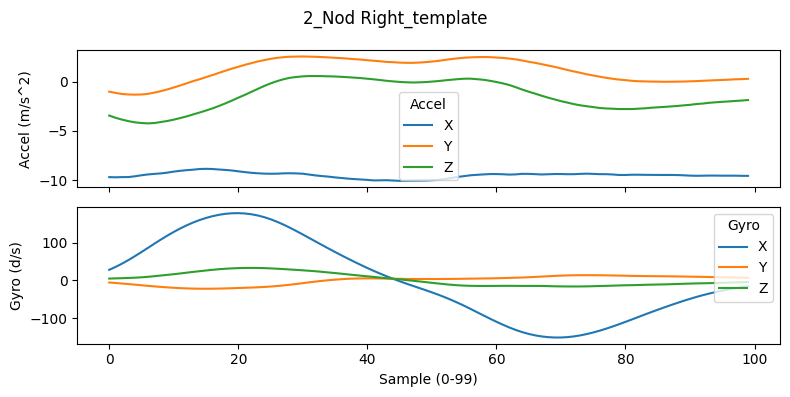

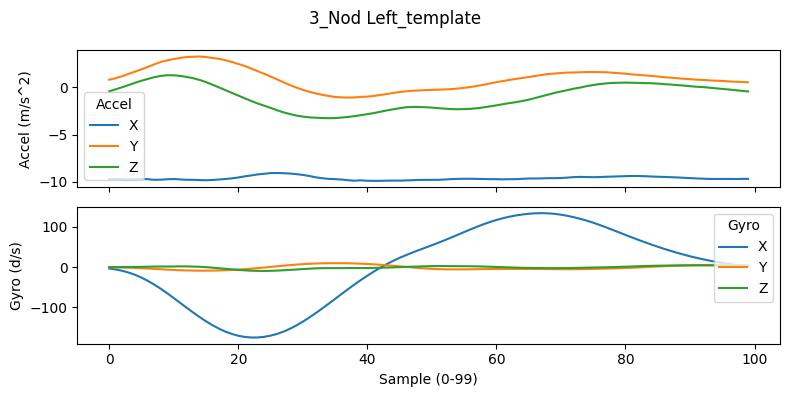

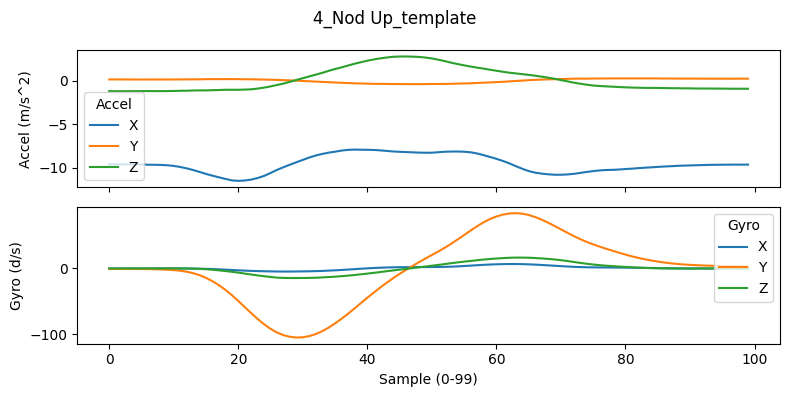

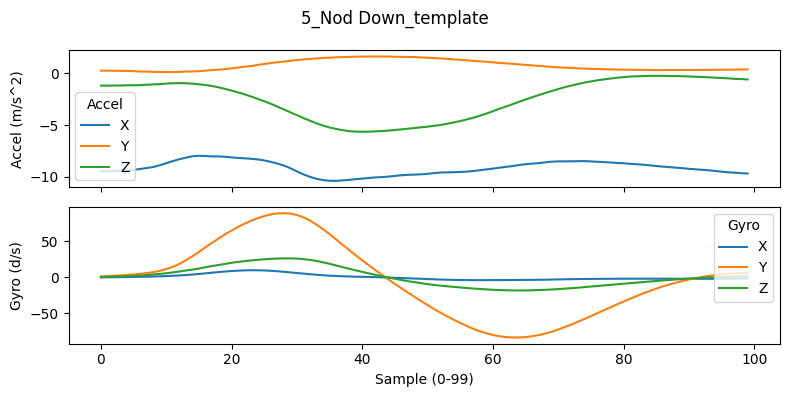

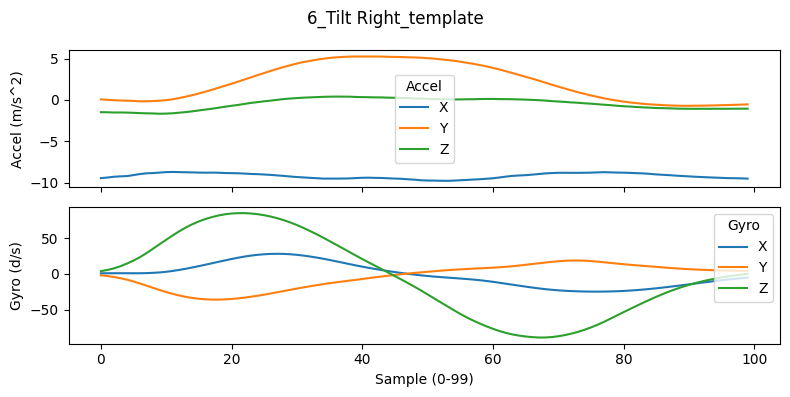

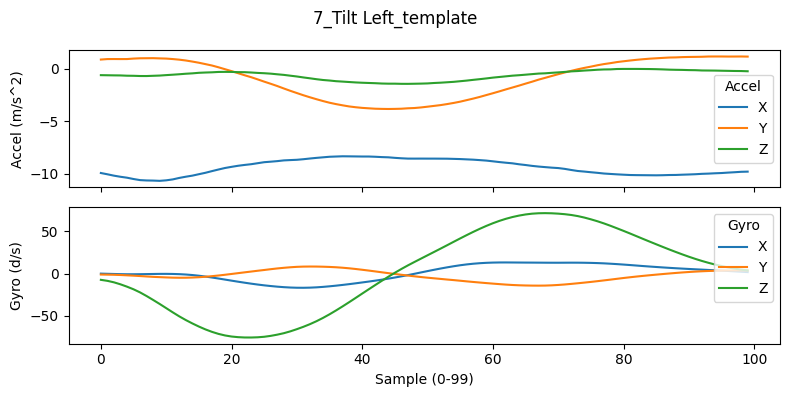

In [41]:
# Plot all 6 gesture templates

data_dir = base_dir / "gesture_templates"
csv_paths = sorted(data_dir.glob(pattern))

for csv_path in csv_paths:
    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))
    idx = np.arange(len(df))

    ax[0].plot(idx, df[["Ax", "Ay", "Az"]], label=("X", "Y", "Z"))
    ax[0].set_ylabel("Accel (m/s^2)")
    ax[0].legend(title="Accel")

    ax[1].plot(idx, df[["Gx", "Gy", "Gz"]], label=("X", "Y", "Z"))
    ax[1].set_ylabel("Gyro (d/s)")
    ax[1].legend(title="Gyro")
    ax[1].set_xlabel("Sample (0-99)")

    fig.suptitle(f"{csv_path.stem}")
    fig.tight_layout()
    plt.show()

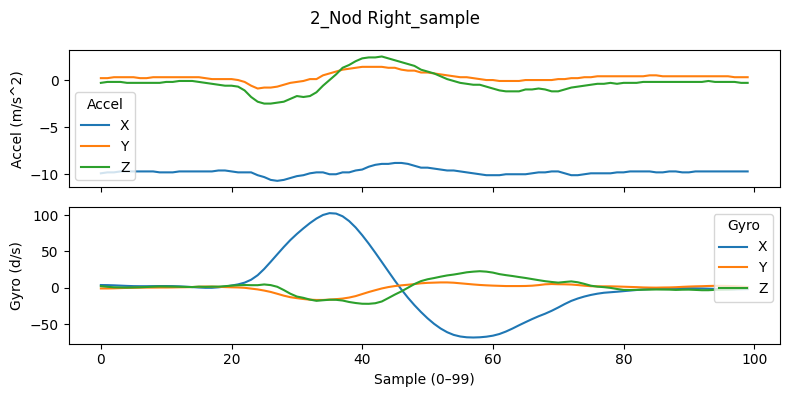

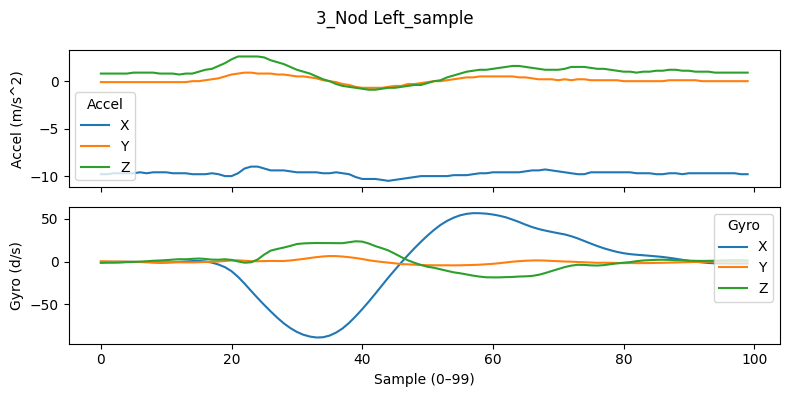

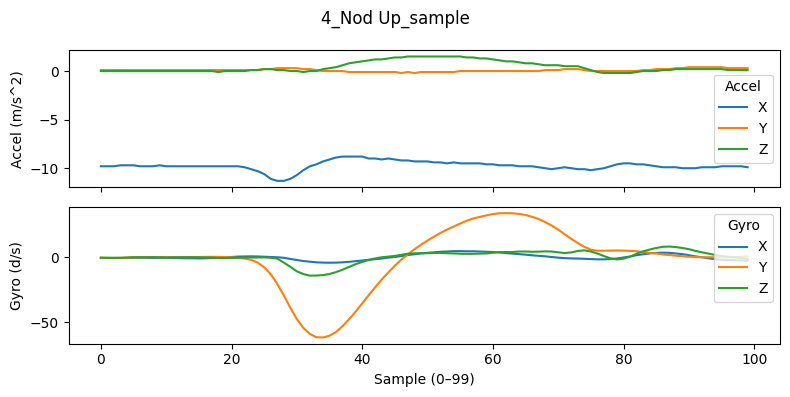

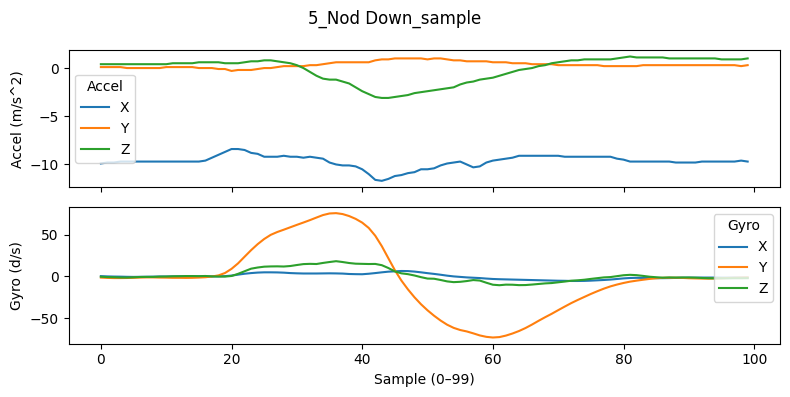

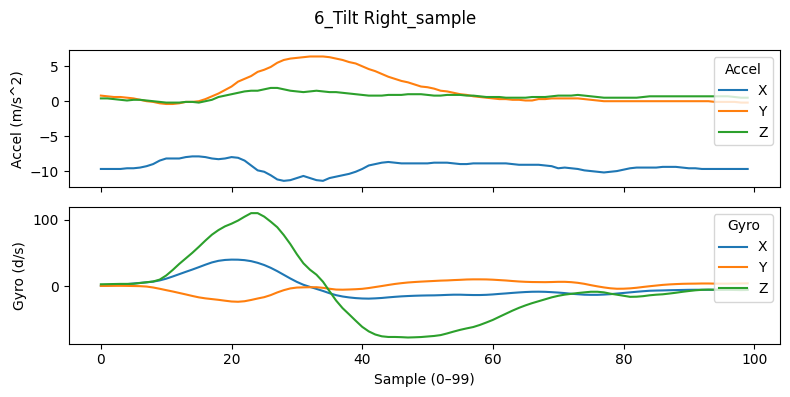

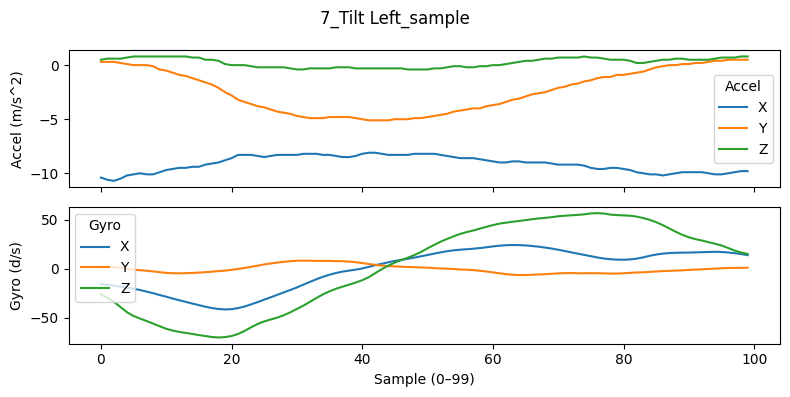

In [42]:
# Plot all 6 gesture samples

data_dir = base_dir / "gesture_samples"
csv_paths = sorted(data_dir.glob(pattern))

for csv_path in csv_paths:
    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))

    idx = np.arange(len(df))

    ax[0].plot(idx, df[["Ax", "Ay", "Az"]], label=("X", "Y", "Z"))
    ax[0].set_ylabel("Accel (m/s^2)")
    ax[0].legend(title="Accel")

    ax[1].plot(idx, df[["Gx", "Gy", "Gz"]], label=("X", "Y", "Z"))
    ax[1].set_ylabel("Gyro (d/s)")
    ax[1].legend(title="Gyro")
    ax[1].set_xlabel("Sample (0–99)")

    fig.suptitle(f"{csv_path.stem}")
    fig.tight_layout()
    plt.show()

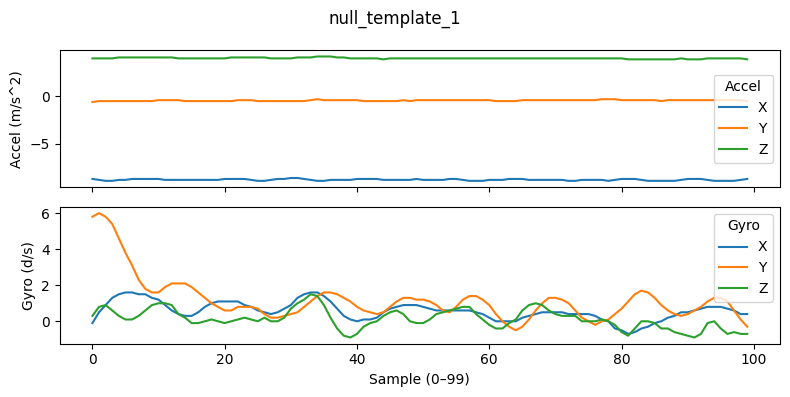

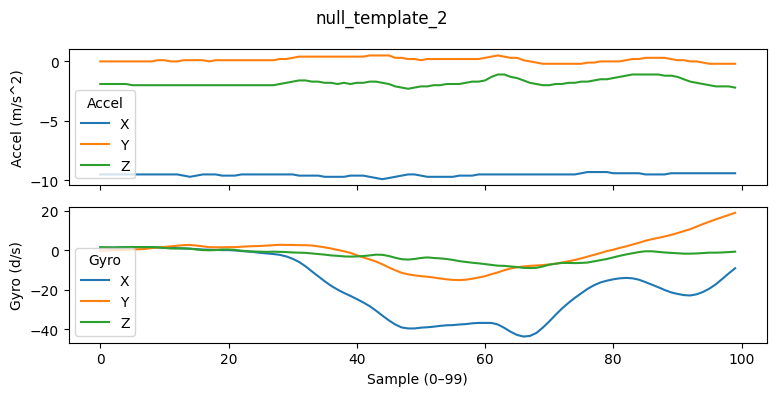

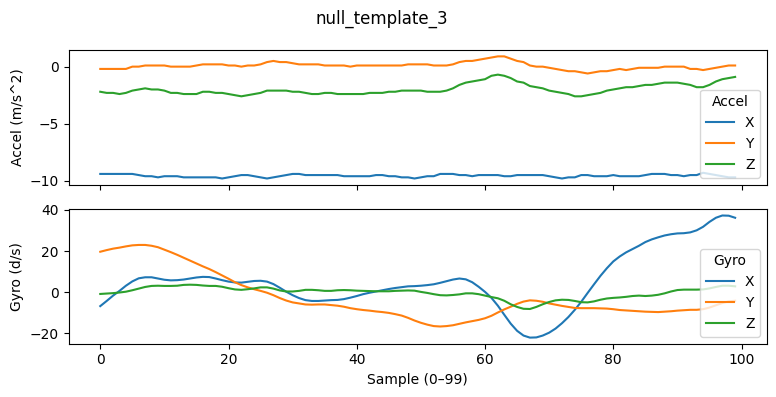

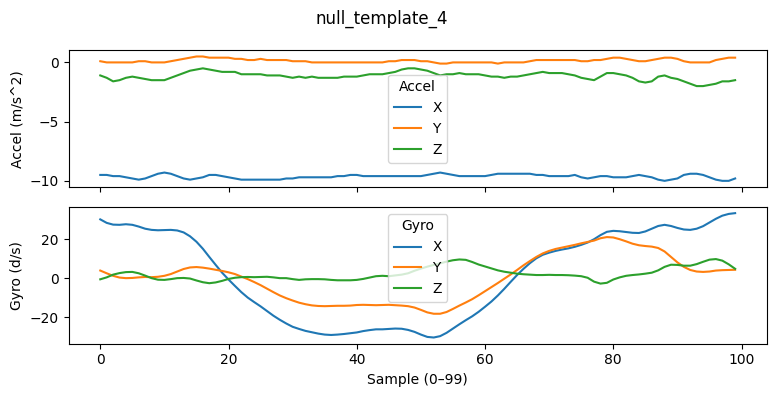

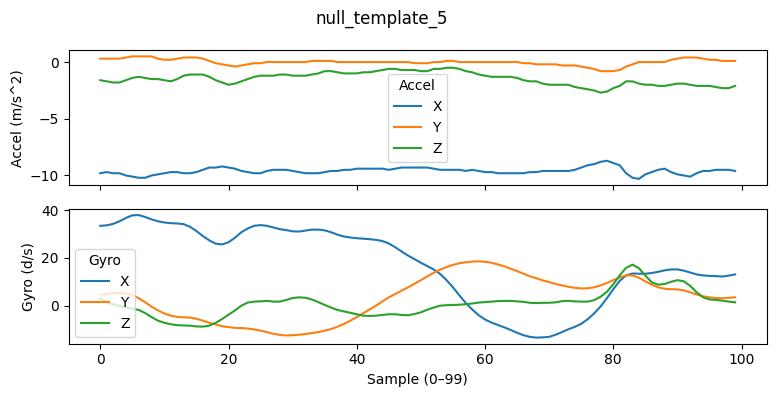

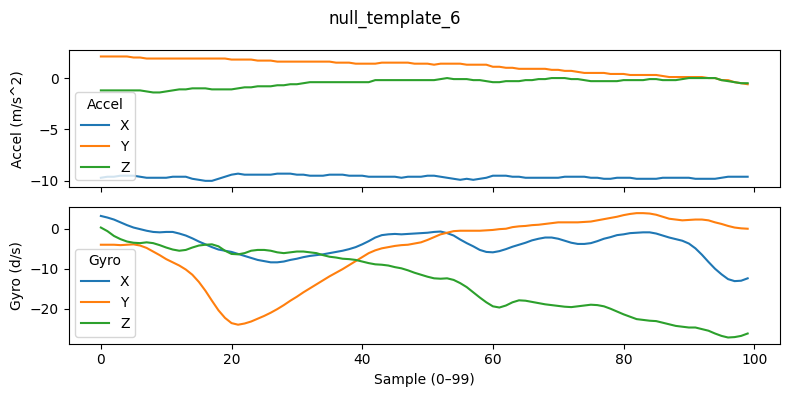

In [43]:
# Plot 6 sample null windows

data_dir = base_dir / "null_templates"
csv_paths = sorted(data_dir.glob(pattern))

for csv_path in csv_paths:
    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))

    idx = np.arange(len(df))

    ax[0].plot(idx, df[["Ax", "Ay", "Az"]], label=("X", "Y", "Z"))
    ax[0].set_ylabel("Accel (m/s^2)")
    ax[0].legend(title="Accel")
    
    ax[1].plot(idx, df[["Gx", "Gy", "Gz"]], label=("X", "Y", "Z"))
    ax[1].set_ylabel("Gyro (d/s)")
    ax[1].legend(title="Gyro")
    ax[1].set_xlabel("Sample (0–99)")

    fig.suptitle(f"{csv_path.stem}")
    fig.tight_layout()
    plt.show()

In [44]:
# Z-score and crosscorr equations

#Z-score
def zscore(a):
    return (a - a.mean(axis=0)) / (a.std(axis=0) + eps)

#Cross-correlation
def crosscorr(a, b):
    a_hat = zscore(a)
    b_hat = zscore(b)
    num = np.sum(a_hat * b_hat, axis=0)
    denom = np.sqrt(np.sum(a_hat**2, axis=0) * np.sum(b_hat**2, axis=0)) + eps
    r = num / denom
    return float(np.mean(r))

# Cross-correlation per channel
def crosscorr_per_channel(a: np.ndarray, b: np.ndarray, eps: float = eps) -> np.ndarray:
    T = min(a.shape[0], b.shape[0])
    a = a[:T]
    b = b[:T]

    a_hat = zscore(a)
    b_hat = zscore(b)

    num   = np.sum(a_hat * b_hat, axis=0)
    denom = np.sqrt(np.sum(a_hat**2, axis=0) * np.sum(b_hat**2, axis=0)) + eps
    r_vec = num / denom

    return r_vec

# Flattened z_score
def flat_zscore(a, acc_idx=(0,1,2), gyro_idx=(3,4,5)):
    a=np.asarray(a, dtype=float).copy()
    
    g = a[:, gyro_idx]                              
    g_mean_t = g.mean(axis=1, keepdims=True)        
    a[:, gyro_idx] = g - g_mean_t                   

    acc = a[:, acc_idx]                             
    acc_mean_t = acc.mean(axis=1, keepdims=True)    
    a[:, acc_idx] = acc - acc_mean_t                

    mu = a.mean()                                   
    sigma = a.std()
    a = (a - mu) / (sigma + eps)

    return a

# Cross-correlation using flattened zscore
def flat_crosscorr(a, b):
    a_hat = flat_zscore(a)
    b_hat = flat_zscore(b)
    num = np.sum(a_hat * b_hat, axis=0)
    denom = np.sqrt(np.sum(a_hat**2, axis=0) * np.sum(b_hat**2, axis=0)) + eps
    r = num / denom
    return float(np.mean(r))

In [45]:
# Calculate cross-correlation between 6 templates and 12 samples

template_dir        = base_dir / "gesture_templates"
gesture_samples_dir = base_dir / "gesture_samples"
null_samples_dir    = base_dir / "null_templates"


template_files        = sorted(template_dir.glob(pattern))
gesture_sample_files  = sorted(gesture_samples_dir.glob(pattern))
null_sample_files     = sorted(null_samples_dir.glob(pattern))

zscore_dir = base_dir / "zscore_templates"
zscore_dir.mkdir(exist_ok=True)

print(f"Found {len(template_files)} templates, "
      f"{len(gesture_sample_files)} gesture samples, "
      f"{len(null_sample_files)} null samples.")

templates = {
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()
    for f in template_files
}
g_samples = {
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()
    for f in gesture_sample_files
}
n_samples = {
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()
    for f in null_sample_files
}


for name, arr in templates.items():
    z_arr = zscore(arr)
    z_arr = np.round(z_arr, 1)
    df = pd.DataFrame(z_arr, columns=imu_cols)
    save_path = zscore_dir / f"{name}_zscore.csv"
    df.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print(f"\nAll normalized templates saved to: {zscore_dir}")


rows = []

# --- compare each gesture sample to all templates ---
for cmp_name, cmp_arr in g_samples.items():
    for tgt_name, tgt_arr in templates.items():
        rows.append({
            "compare_name": cmp_name,
            "target_template": tgt_name,
            "r": crosscorr(tgt_arr, cmp_arr),
        })

# --- compare each null sample to all templates ---
for cmp_name, cmp_arr in n_samples.items():
    for tgt_name, tgt_arr in templates.items():
        rows.append({
            "compare_name": cmp_name,
            "target_template": tgt_name,
            "r": crosscorr(tgt_arr, cmp_arr),
        })

results = (
    pd.DataFrame(rows)
      .sort_values(["compare_name", "target_template"])
      .reset_index(drop=True)
)

print(f"\nGenerated {len(results)} cross-correlation values "
      f"(({len(gesture_sample_files)} + {len(null_sample_files)}) * {len(template_files)}).")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(results.assign(r=lambda df: df["r"].round(3)))


Found 6 templates, 6 gesture samples, 6 null samples.
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\2_Nod Right_template_zscore.csv
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\3_Nod Left_template_zscore.csv
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\4_Nod Up_template_zscore.csv
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\5_Nod Down_template_zscore.csv
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\6_Tilt Right_template_zscore.csv
Saved: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates\7_Tilt Left_template_zscore.csv

All normalized templates saved to: c:\Repositories\gesture_models\Cross Correlation Models\1_Sandra_glasses_test\zscore_templates

Generated 72 c

,compare_name,target_template,r
0,2_Nod Right_sample,2_Nod Right_template,-0.026
1,2_Nod Right_sample,3_Nod Left_template,-0.407
2,2_Nod Right_sample,4_Nod Up_template,0.201
3,2_Nod Right_sample,5_Nod Down_template,-0.183
4,2_Nod Right_sample,6_Tilt Right_template,0.104
5,2_Nod Right_sample,7_Tilt Left_template,-0.307
6,3_Nod Left_sample,2_Nod Right_template,0.075
7,3_Nod Left_sample,3_Nod Left_template,0.377
8,3_Nod Left_sample,4_Nod Up_template,-0.268
9,3_Nod Left_sample,5_Nod Down_template,0.264


In [46]:
# Calculate per-channel cross-correlation between templates and given sample


template_dir_path = base_dir / "gesture_templates"
sample_csv_path   = Path("C:\Repositories\gesture_models\Cross Correlation Models/1_Sandra_glasses_test\gesture_templates/7_Tilt Left_template.csv") 


template_files = sorted(Path(template_dir_path).glob(pattern))
if not template_files:
    raise FileNotFoundError(f"No CSVs found in {template_dir_path} matching '{pattern}'.")

templates = {
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()
    for f in template_files
}

sample_name = sample_csv_path.stem
sample_arr  = pd.read_csv(sample_csv_path, usecols=imu_cols)[imu_cols].to_numpy()

rows = []
index_names = []
for tmpl_name, tmpl_arr in templates.items():
    r_vec = crosscorr_per_channel(tmpl_arr, sample_arr)
    rows.append(r_vec)
    index_names.append(tmpl_name)

per_channel_df = pd.DataFrame(rows, index=index_names, columns=imu_cols)

print(f"Sample compared: {sample_name}")
print("Per-channel cross-correlations (templates × channels):")
print(per_channel_df.round(2))



Sample compared: 7_Tilt Left_template
Per-channel cross-correlations (templates × channels):
                         Ax    Ay    Az    Gx    Gy    Gz
2_Nod Right_template  -0.53 -0.86 -0.65 -0.85 -0.27 -0.98
3_Nod Left_template   -0.08  0.76  0.72  0.88  0.80  0.50
4_Nod Up_template      0.60  0.94 -0.88  0.84 -0.89  0.86
5_Nod Down_template   -0.53 -0.98  0.93 -0.82  0.86 -0.96
6_Tilt Right_template -0.66 -0.99 -0.62 -0.94 -0.51 -1.00
7_Tilt Left_template   1.00  1.00  1.00  1.00  1.00  1.00


<>:5: SyntaxWarning: invalid escape sequence '\R'
<>:5: SyntaxWarning: invalid escape sequence '\R'
C:\Users\sandr\AppData\Local\Temp\ipykernel_10576\3491256297.py:5: SyntaxWarning: invalid escape sequence '\R'
  sample_csv_path   = Path("C:\Repositories\gesture_models\Cross Correlation Models/1_Sandra_glasses_test\gesture_templates/7_Tilt Left_template.csv")


    Ax   Ay   Az   Gx   Gy   Gz  GestureLabel
0 -8.7 -0.6  4.0 -0.1  5.8  0.3             1
1 -8.8 -0.5  4.0  0.5  6.0  0.8             1
Per-class counts in sample: {np.int64(1): 50, np.int64(2): 50, np.int64(3): 50, np.int64(4): 50, np.int64(5): 50, np.int64(6): 50, np.int64(7): 50}
# extracted gestures: 350
# extracted gesture class labels: 350
Shape of sample arrays: {(100, 6)}
Gesture class labels of sample array: [1 2 3 4 5 6 7]
# predicted class labels 350


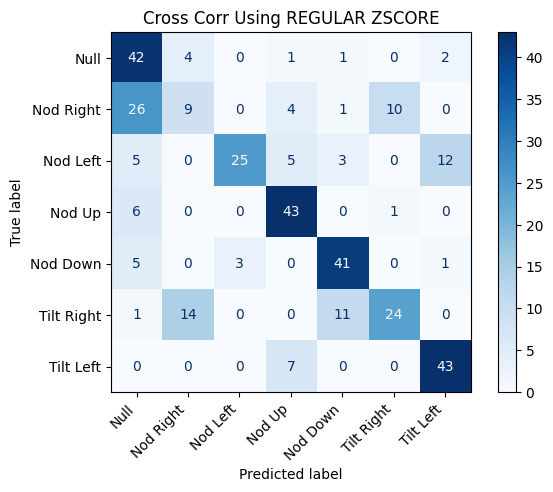

In [47]:
# Predict the class of 350 gestures & generate confusion matrix using REGULAR ZSCORE
# Using OOTB2 data

test_data_path = base_dir/"Data"/"COMPOSITE_Head_gestures_renum_PROCESSED.csv"
template_dir = base_dir/"gesture_templates"


# Load templates

template_files        = sorted(template_dir.glob(pattern))
templates = {                                                       #templates = dictionary
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()       
    for f in template_files
}


# Load OOTB2 test data & select 50 random gestures (full dataset was too large)

test_data = pd.read_csv(test_data_path)
test_arr=[]
class_arr=[]
print(test_data.head(2))

win = 100
rng = random.Random(42)   
K = 50                    # gestures per class

gestures = []  
for i in range(0, len(test_data), win):
    chunk = test_data.iloc[i:i+win]
    X   = chunk.iloc[:, 0:6].to_numpy()   
    y   = chunk.iloc[0, 6]                
    gestures.append((y, X))

by_class = defaultdict(list)
for y, X in gestures:
    by_class[y].append(X)

sampled_test_arr  = []
sampled_class_arr = []

for y, windows in by_class.items():
    pick = rng.sample(windows, k=min(K, len(windows)))
    sampled_test_arr.extend(pick)
    sampled_class_arr.extend([y] * len(pick))               # sampled_test_arr = list

# Sanity checks for extracted samples

print("Per-class counts in sample:", {y: sampled_class_arr.count(y) for y in by_class})
print("# extracted gestures:", len(sampled_test_arr))
print("# extracted gesture class labels:", len(sampled_class_arr))
unique_shapes = {arr.shape for arr in sampled_test_arr}            
print("Shape of sample arrays:", unique_shapes)
print("Gesture class labels of sample array:", np.unique(sampled_class_arr))



# Find cross correlation between gesture in sampled_test_arr and the six templates

r = []
for test in sampled_test_arr:
    test_r=[]
    for tgt_name, tgt_arr in templates.items():
        test_r.append(crosscorr(tgt_arr, test))    
    r.append(test_r)


# Use r values to predict class labels

predicted_classes = []
threshold = 0.4

for test_r in r:
    arr = np.array(test_r)
    if np.all(arr < threshold):
        predicted_classes.append(1)
    else:
        idx = int(np.argmax(arr))
        predicted_classes.append(
            idx+2)
print("# predicted class labels", len(predicted_classes))


#Generate confusion matrix

class_names = ["Null", "Nod Right", "Nod Left", "Nod Up", "Nod Down", "Tilt Right", "Tilt Left"]
cm = confusion_matrix(sampled_class_arr, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Cross Corr Using REGULAR ZSCORE")
plt.show()




    Ax   Ay   Az   Gx   Gy   Gz  GestureLabel
0 -8.7 -0.6  4.0 -0.1  5.8  0.3             1
1 -8.8 -0.5  4.0  0.5  6.0  0.8             1
Per-class counts in sample: {np.int64(1): 150, np.int64(2): 150, np.int64(3): 150, np.int64(4): 150, np.int64(5): 150, np.int64(6): 150, np.int64(7): 150}
# extracted gestures: 1050
# extracted gesture class labels: 1050
Shape of sample arrays: {(100, 6)}
Gesture class labels of sample array: [1 2 3 4 5 6 7]
# predicted class labels 1050


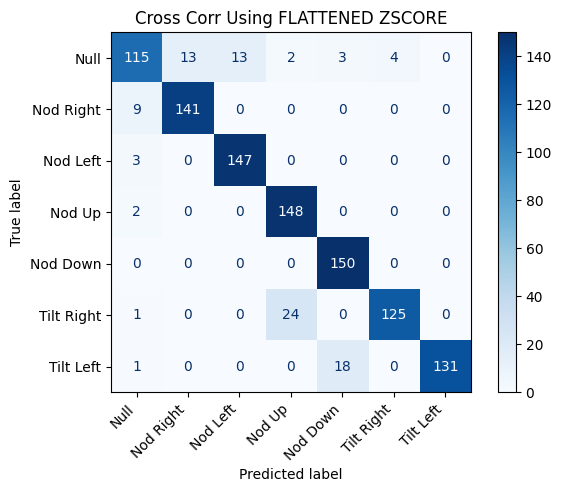

In [53]:
# Predict the class of 350 gestures & generate confusion matrix using FLATTENED ZSCORE
# Using OOTB2 data

test_data_path = base_dir/"Data"/"COMPOSITE_Head_gestures_renum_PROCESSED.csv"
template_dir = base_dir/"gesture_templates"
pattern = "*.csv"
imu_cols     = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]

# Load templates

template_files        = sorted(template_dir.glob(pattern))
templates = {                                                       #templates = dictionary
    f.stem: pd.read_csv(f, usecols=imu_cols)[imu_cols].to_numpy()       
    for f in template_files
}


# Load OOTB2 test data & select 50 random gestures (full dataset was too large)

test_data = pd.read_csv(test_data_path)
test_arr=[]
class_arr=[]
print(test_data.head(2))

win = 100
rng = random.Random(42)   
K = 150                    # gestures per class

gestures = []  
for i in range(0, len(test_data), win):
    chunk = test_data.iloc[i:i+win]
    X   = chunk.iloc[:, 0:6].to_numpy()   
    y   = chunk.iloc[0, 6]                
    gestures.append((y, X))

by_class = defaultdict(list)
for y, X in gestures:
    by_class[y].append(X)

sampled_test_arr  = []
sampled_class_arr = []

for y, windows in by_class.items():
    pick = rng.sample(windows, k=min(K, len(windows)))
    sampled_test_arr.extend(pick)
    sampled_class_arr.extend([y] * len(pick))               # sampled_test_arr = list

# Sanity checks for extracted samples

print("Per-class counts in sample:", {y: sampled_class_arr.count(y) for y in by_class})
print("# extracted gestures:", len(sampled_test_arr))
print("# extracted gesture class labels:", len(sampled_class_arr))
unique_shapes = {arr.shape for arr in sampled_test_arr}            
print("Shape of sample arrays:", unique_shapes)
print("Gesture class labels of sample array:", np.unique(sampled_class_arr))



# Find cross correlation between gesture in sampled_test_arr and the six templates

r = []
for test in sampled_test_arr:
    test_r=[]
    for tgt_name, tgt_arr in templates.items():
        test_r.append(flat_crosscorr(tgt_arr, test))    
    r.append(test_r)


# Use r values to predict class labels

predicted_classes = []
threshold = 0.7

for test_r in r:
    arr = np.array(test_r)
    if np.all(arr < threshold):
        predicted_classes.append(1)
    else:
        idx = int(np.argmax(arr))
        predicted_classes.append(
            idx+2)
print("# predicted class labels", len(predicted_classes))


#Generate confusion matrix

class_names = ["Null", "Nod Right", "Nod Left", "Nod Up", "Nod Down", "Tilt Right", "Tilt Left"]
cm = confusion_matrix(sampled_class_arr, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Cross Corr Using FLATTENED ZSCORE")
plt.show()


